# Optimal Transport

## Importations and tools functions

### Importations

In [5]:
%pip install sympy
%pip install POT

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import seaborn as sns
import numpy as np
import ot
import ot.plot
import sklearn.metrics as sme
import matplotlib.pylab as pl

from warnings import warn
from sympy import Interval, Union

In [17]:
bases_list = ["AAA", "AAC", "CAC", "CAA", "CCC", "CCA", "ACC", "ACA"]

data_path = "/home/onyxia/work/Data/"

In [25]:
dfs = {}

for base in bases_list:
    dfs[base] = pd.read_csv(f"{data_path}angles_RNA_{base}.csv")

df_all_angles = pd.concat(dfs, axis=1)

In [19]:
mid_angles = {}
first_angles = {}
last_angles = {}

cols_to_drop = ["res_id", "res_name"]

for base in bases_list:
    
    mid_angles[base] = dfs[base][dfs[base]["res_id"].isin([2])].drop(columns=cols_to_drop)
    first_angles[base] = dfs[base][dfs[base]["res_id"].isin([1])].drop(columns=cols_to_drop)
    last_angles[base] = dfs[base][dfs[base]["res_id"].isin([3])].drop(columns=cols_to_drop)

mid_angles["AAA"]

,chain,alpha,beta,gamma,delta,epsilon,zeta,nu0,nu1,nu2,nu3,nu4,eta,theta,chi
1,B,305.490140,162.730043,52.603131,78.995842,214.526967,278.473410,0.070455,336.709644,36.383089,322.671813,23.477230,168.948446,209.995984,189.233622
4,B,146.988674,193.708737,179.793685,81.382929,225.230787,283.202503,8.016439,330.418764,38.904281,324.713641,17.215873,159.669284,195.684487,179.675616
7,B,301.320403,163.375457,50.046480,75.955382,223.673354,292.092174,4.371440,330.290735,42.360514,319.319860,22.886112,163.017130,223.839931,192.378723
10,B,295.578929,176.137498,64.087720,81.199826,209.114531,292.686375,358.939293,337.072121,36.751825,321.620907,24.848753,174.891792,219.747934,184.549837
13,B,301.868572,168.989858,52.243122,80.262432,210.286872,280.323108,0.935298,336.664007,35.627748,323.916667,22.172684,169.729129,208.902042,193.628678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18052,B,359.243083,115.818572,66.577611,83.483783,186.120445,256.786693,7.027008,332.352175,36.700126,326.430947,16.744271,185.351610,221.568289,297.780053
18055,B,143.786438,216.118476,186.337421,148.069144,208.983270,216.610609,338.920824,36.099064,323.462945,25.241961,357.198641,190.847730,170.360477,291.694825
18058,B,40.453015,250.096048,248.807834,147.528139,263.262144,71.416625,339.036145,35.579300,324.210889,24.606173,357.511716,230.553841,16.753732,50.805860
18061,B,160.606135,190.562729,173.702897,91.886990,229.348767,292.482836,17.771124,325.291458,37.452448,331.822386,6.719794,219.537182,209.696504,185.924817


In [20]:
mid_6angles = {}
first_6angles = {}
last_6angles = {}
mid_nu = {}
first_nu = {}
last_nu = {}

for base in bases_list:

    mid_6angles[base] = mid_angles[base][["alpha", "beta", "gamma", "delta", "epsilon", "zeta"]]
    first_6angles[base] = first_angles[base][["alpha", "beta", "gamma", "delta", "epsilon", "zeta"]]
    last_6angles[base] = last_angles[base][["alpha", "beta", "gamma", "delta", "epsilon", "zeta"]]
    
    mid_nu[base] = mid_angles[base][["nu0", "nu1", "nu2", "nu3", "nu4"]]
    first_nu[base] = first_angles[base][["nu0", "nu1", "nu2", "nu3", "nu4"]]
    last_nu[base] = last_angles[base][["nu0", "nu1", "nu2", "nu3", "nu4"]]

### Tool functions

In [93]:
def tore_dist(x, y):
    angle_value = 360.0
    half_val = 180.0
    
    dist_sq = 0.0
    for i in range(len(x)):
        diff = x[i] - y[i]
        short_diff = (diff + half_val) % angle_value - half_val
        dist_sq += short_diff**2
        
    return np.sqrt(dist_sq)

In [8]:
def quadra_cost(x,y):
    return((x - y)**2)

## Distance calculation

In [106]:
def bins_generator(mean_val, bins):
    
    if (bins > 180): 
        raise ValueError("Bins cannot be bigger than 180°")

    diffMbins = mean_val - bins
    sumMbins = mean_val + bins
    
    if (diffMbins < 0):
        int1 = Interval(0, mean_val)
        int2 = Interval(diffMbins % 360, 360)
        bound_inf = Union(int1, int2)
        bound_sup = Interval(mean_val, sumMbins)
        return(Union(bound_inf, bound_sup))
        
    elif (sumMbins > 360):
        int1 = Interval(0, sumMbins % 360)
        int2 = Interval(mean_val, 360)
        bound_sup = Union(int1, int2)
        bound_inf = Interval(diffMbins, mean_val)
        return(Union(bound_inf, bound_sup))
        
    else :
        return(Interval(diffMbins,sumMbins))

In [107]:
bins_generator(355,15)

Union(Interval(0, 10), Interval(340, 360))

In [121]:
is_stable = np.vectorize(lambda x: x in bins_generator(305,5))

In [122]:
xs = mid_6angles['AAA'][is_stable(mid_6angles['AAA']["alpha"])][["alpha", "beta"]].to_numpy()
xt = mid_6angles["AAA"][["alpha", "beta"]].to_numpy()

In [123]:
cost_matrix = ot.dist(xs, xt, metric = tore_dist)

In [124]:
a, b = np.ones(len(xs))/len(xs), np.ones(len(xt))/len(xt)

In [125]:
test = ot.solve(cost_matrix, a, b)

In [126]:
test.plan

array([[0.00016606, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00016606, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(666, 6022))

In [127]:
test.value

65.88432680778456

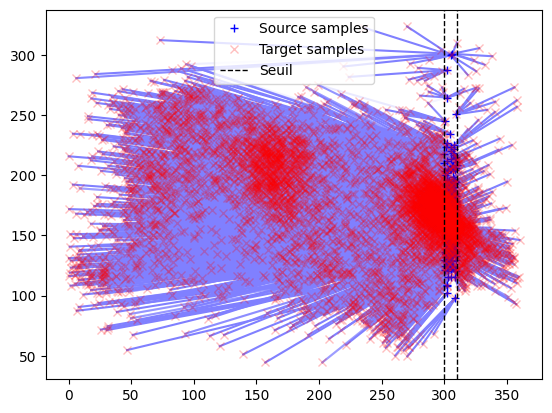

In [138]:
ot.plot.plot2D_samples_mat(xs, xt, test.plan, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target samples", alpha = .25)
pl.axvline(x = min(xs[:, 0]), color="black", linestyle="--", linewidth=1)
pl.axvline(x = max(xs[:, 0]), color="black", linestyle="--", linewidth=1, label="Seuil")
pl.legend(loc=0)

In [139]:
len(xs)*180/20

5994.0